# 3. Editing State & Human Feedback

How to "pause" the LLM to request for human input (e.g stopping to get permission to perform a task, or prompting the user for additional feedback) then adding that to the state before continuing on in the graph

| Date | User | Change Type | Remarks |  
| ---- | ---- | ----------- | ------- |
|  25/05/26  | Martin | CREATE   | Started Module 3. Streaming types | 
|  26/05/26  | Martin | CREATE   | Finished Module 3. Streaming, Breakpoints and Time Travel | 

# Content

* [Streaming](#streaming)
* [Breakpoints](#breakpoints)
* [Time Travel](#time-travel)

# Streaming

Streaming is when the graph actively prints out its "thought-process". Here it is the graph state.

`.stream` and `.astream` are the sync and async versions for streaming results back.

Langgraph has 2 different modes for streaming:

- `values`: Streams the __full state__ of the graph after each node is called
- `updates`: Streams only the __updated__ to the graph after each node is called

In [3]:
import os
from dotenv import load_dotenv
from typing import Literal
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)

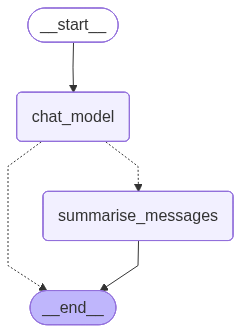

In [2]:
class State(MessagesState):
    summary: str

def chat_model(state: State):
    """
    Chat model that appends the summary before the user messages if it exists
    """
    summary = state.get("summary", "")
    if summary:
        summary_message = f"This is the current summary of the conversation: {summary}"

        # Add the summary message to the existing conversation
        messages = [SystemMessage(content=summary_message)] + state['messages']
    else:
        messages = state['messages']

    output = llm.invoke(messages)
    return {"messages": output}

def summarise_messages(state: State):
    """
    Creates or appends to the summary of the conversation before adding it to the state
    """
    summary = state.get("summary", "")
    if summary:
        new_summary = (
            f"The current summary of the conversation is {summary}"
            "Please extend the summary with the current message above:"
        )
    else:
        new_summary = "Create a summary based on the current messages above:"

    # Only creates the summary
    message_w_summary = state['messages'] + [HumanMessage(content=new_summary)]
    output = llm.invoke(message_w_summary)

    # Delete all but 2 of the most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {"summary": output.content, "messages": delete_messages}

def should_continue(state: State) -> Literal["summarise_messages", END]:
    """Return the next node to execute"""
    messages = state['messages']

    # Threshold here includes the AI messages
    if len(messages) > 6:
        return "summarise_messages"

    return END

# Define the graph
workflow = StateGraph(State)

workflow.add_node("chat_model", chat_model)
workflow.add_node("summarise_messages", summarise_messages)

workflow.add_edge(START, "chat_model")
workflow.add_conditional_edges("chat_model", should_continue)
workflow.add_edge("summarise_messages", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
# Thread
config = {"configurable": {"thread_id": "1"}}

# Streaming mode = updates
for chunk in graph.stream(
    {"messages": [ HumanMessage(content="Hi I'm Martin") ]}, config, stream_mode='updates'
):
    print(chunk)
    print("===== Conversation =====")
    print(chunk['chat_model']['messages'].pretty_print())

{'chat_model': {'messages': AIMessage(content='Hello Martin. How are you today? Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 39, 'total_tokens': 63, 'completion_time': 0.031800731, 'completion_tokens_details': None, 'prompt_time': 0.027615316, 'prompt_tokens_details': None, 'queue_time': 0.067157034, 'total_time': 0.059416047}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6278-b736-7c52-87f8-0d7ef9df400e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 24, 'total_tokens': 63})}}
===== Conversation =====
================================== Ai Message ==================================

Hello Martin. How are you today? Is there something I can help you with or would you like to c

In [ ]:
# Another thread
config = {"configurable": {"thread_id": "2"}}

# Streaming mode = updates
for event in graph.stream(
    {"messages": [ HumanMessage(content="Hi I'm Martin") ]}, config, stream_mode='values'
):
    for m in event['messages']:
        m.pretty_print()
    print('-'*25)

================================ Human Message =================================

Hi I'm Martin
-------------------------
================================ Human Message =================================

Hi I'm Martin
================================== Ai Message ==================================

Hi Martin, it's nice to meet you. Is there something I can help you with or would you like to chat?
-------------------------


## Streaming Tokens

Where the LLM stream tokens as they are generated. Use `.astream_events` method

Each dict contains the following keys:

- `event`: Type of event that is being emitted
- `name`: Name of the event
- `data`: Data associated with the event
- `metadata`: Contains `langgraph_node`, node emitting the event

In [ ]:
# Show the metadata of the streaming event
config = {"configurable": {"thread_id": "4"}}
input_msg = HumanMessage(content="Tell me about the Golden State Warriors")
async for event in graph.astream_events(
    {"messages": [ input_msg ]}, config, version="v2"
):
    print(
        f"Node: {event['metadata'].get('langgraph_node', '')}. "
        f"Type: {event['event']}. "
        f"Name: {event['name']}"
    )

Node: ,Type: on_chain_startName: LangGraph
Node: chat_model,Type: on_chain_startName: chat_model
Node: chat_model,Type: on_chat_model_startName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_model_streamName: ChatGroq
Node: chat_model,Type: on_chat_mod

In [8]:
# Printing the actual message
node_to_stream = "chat_model"
config = {"configurable": {"thread_id": "5"}}
input_msg = HumanMessage(content="Tell me about Shohei Ohtani")
final_msg = ""
async for event in graph.astream_events(
    {"messages": [input_msg]}, config, version="v2"
):
    if event["event"] == "on_chat_model_stream" \
    and event['metadata'].get('langgraph_node', '') == node_to_stream:
        data = event['data']
        final_msg += data['chunk'].content
print(final_msg)

**The Rise of a Baseball Phenom: Shohei Ohtani**

Shohei Ohtani is a Japanese professional baseball player who has taken the world of baseball by storm. Born on July 5, 1994, in Oshu, Iwate, Japan, Ohtani is a 6-foot-4-inch, 215-pound right-hander who plays for the Los Angeles Angels of Major League Baseball (MLB). He is a rare talent who excels in both hitting and pitching, making him one of the most unique and exciting players in the game today.

**Early Life and Career**

Ohtani began playing baseball at a young age and quickly showed promise as a pitcher and hitter. He attended Hanamaki Higashi High School, where he helped lead the team to several championships. In 2012, he was selected by the Hokkaido Nippon-Ham Fighters in the first round of the Nippon Professional Baseball (NPB) draft.

**NPB Career**

Ohtani made his professional debut with the Fighters in 2013, and by 2016, he had established himself as one of the top pitchers in the league. In 2017, he won the NPB MVP award, 

## Connecting to Hosted Agents

Connect to LangSmith using Langgraph API

In [1]:
from langgraph_sdk import get_client

URL = "http://localhost:2024"
client = get_client(url=URL)

assistants = await client.assistants.search()
assistants

[{'assistant_id': 'fe096781-5601-53d2-b2f6-0d3403f7e9ca',
  'graph_id': 'agent',
  'config': {},
  'context': {},
  'metadata': {'created_by': 'system'},
  'name': 'agent',
  'created_at': '2026-05-26T04:29:43.871859+00:00',
  'updated_at': '2026-05-26T04:29:43.871859+00:00',
  'version': 1,
  'description': None},
 {'assistant_id': '28d99cab-ad6c-5342-aee5-400bd8dc9b8b',
  'graph_id': 'simple_graph',
  'config': {},
  'context': {},
  'metadata': {'created_by': 'system'},
  'name': 'simple_graph',
  'created_at': '2026-05-26T04:29:43.683533+00:00',
  'updated_at': '2026-05-26T04:29:43.683533+00:00',
  'version': 1,
  'description': None},
 {'assistant_id': '228f9934-0cdd-5383-92c8-ee8422522cc2',
  'graph_id': 'router',
  'config': {},
  'context': {},
  'metadata': {'created_by': 'system'},
  'name': 'router',
  'created_at': '2026-05-20T10:37:02.319768+00:00',
  'updated_at': '2026-05-20T10:37:02.319768+00:00',
  'version': 1,
  'description': None}]

In [ ]:
thread = await client.threads.create()  # Create a new thread for conversation
input_msg = HumanMessage(content="Multiply 4 and 5")

def format_tool_calls(tool_calls):
    if tool_calls:
        formatted_calls = []
        for call in tool_calls:
            formatted_calls.append(
                f"Tool Call ID: {call['id']}, Function: {call['name']}, Args: {call['args']}"
            )
        return "\n".join(formatted_calls)
    return "No tool calls"

async for event in client.runs.stream(
    thread['thread_id'],
    assistant_id='agent',
    input={'messages': [input_msg]},
    stream_mode="messages"  # Unique to the sdk, allows streaming of only message outputs
):
    if event.event == 'metadata':
        print(f"Metadata: Run ID - {event.data['run_id']}")
        print("-" * 50)

    elif event.event == "messages/partial":
        for data_item in event.data:
            if "role" in data_item and data_item['role'] == "user":
                print(f"Human: {data_item['content']}")
            else:
                # Extract relevant data from the event
                tool_calls = data_item.get("tool_calls", [])
                invalid_tool_calls = data_item.get("invalid_tool_calls", [])
                content = data_item.get("content", "")
                response_metadata = data_item.get("response_metadata", {})

                if content:
                    print(f"AI: {content}")

                if tool_calls:
                    print("Tool Calls:")
                    print(format_tool_calls(tool_calls))

                if invalid_tool_calls:
                    print("Invalid Tool Calls:")
                    print(format_tool_calls(invalid_tool_calls))

                if response_metadata and response_metadata.get("finish_reason"):
                    print(f"Response Metadata: Finish Reason - {response_metadata['finish_reason']}")                    
        print("-" * 50)

---

# Breakpoints

Stopping the graph midway for human-in-the-loop intervention. Reasons include

1. __Approval__ - Asking the user to provide additional input or approval
2. __Debugging__ - Diagnose problems within the graph
3. __Editing__ - Modifying the state of the graph

In [ ]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

In [8]:
def multiply(a: int, b: int) -> int:
    """
    Multiply integers a and b together

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Multiplication result of a and b
    """
    return a * b

def add(a: int, b: int) -> int:
    """
    Adds integers a and b together

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Addition result of a and b
    """
    return a + b

def divide(a: int, b: int) -> float:
    """
    Divides integer a and integer b

    Args:
        a (int): Integer 1
        b (int): Integer 2

    Returns:
        int: Division result of a and b
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)
llm_with_tools = llm.bind_tools(tools)

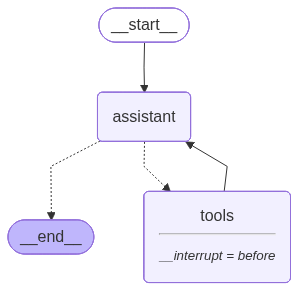

In [9]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
# Will pause before calling the tools node
graph = builder.compile(interrupt_before=["tools"], checkpointer=memory)

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
initial_input = {"messages": "Multiply 2 and 3"}
thread = {"configurable": { "thread_id": 6 }}

# Runs the graph then pauses at the "tools" node
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()


================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (73v1nf4ba)
 Call ID: 73v1nf4ba
  Args:
    a: 2
    b: 3


In [11]:
state = graph.get_state(thread)
state.next

('tools',)

Running `Graph.stream()` will re-emit the current state, which contains the `AIMessage` with tool call

In [13]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (73v1nf4ba)
 Call ID: 73v1nf4ba
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of the multiplication is indeed 6.


Breakpoints can then be used to request for user approval

In [14]:
initial_input = {"messages": "Multiply 4 and 6"}

thread = {"configurable": {"thread_id": "7"}}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

user_approval = input("Do you want to call the tool (yes/ no): ")

if user_approval == "yes":
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 4 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (nh15kj3hf)
 Call ID: nh15kj3hf
  Args:
    a: 4
    b: 6
================================== Ai Message ==================================
Tool Calls:
  multiply (nh15kj3hf)
 Call ID: nh15kj3hf
  Args:
    a: 4
    b: 6
================================= Tool Message =================================
Name: multiply

24
================================== Ai Message ==================================
Tool Calls:
  divide (zgg2j3tft)
 Call ID: zgg2j3tft
  Args:
    a: 24
    b: 4


## Editing State

Updating the state programmatically midway through execution

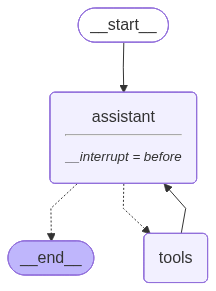

In [15]:
# Reusing the same graph configuration as above
graph = builder.compile(interrupt_before=['assistant'], checkpointer=MemorySaver())

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [17]:
# Update the state using update_state
input_msg = {"messages": "Multiply 2 and 3"}
thread = {"configurable": {"thread_id": "8"}}

for event in graph.stream(input_msg, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# NOTE: Update state happens here
graph.update_state(
    thread,
    {"messages": [HumanMessage("No actually multiply 4 and 8!")]}
)

# Review the new state
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No actually multiply 4 and 8!
================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No actually multiply 4 and 8!


In [18]:
# Continue running the graph
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No actually multiply 4 and 8!
================================== Ai Message ==================================

<multiply>a=4&b=8</multiply>


## Awaiting User Input

Allow for human feedback to perform the state update. Add a node (current unimplemented) that serves as the placeholder for `human_feedback`.

The node allows the user to add feedback directly to state

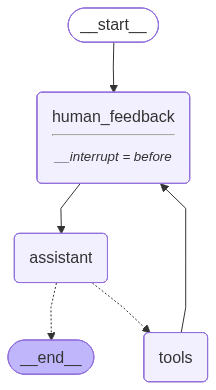

In [20]:
sys_msg = SystemMessage(
    content="You are a helpful assistant tasked with performing arithmic tasks"
)

def human_feedback(state: MessagesState):
    pass

def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state['messages'])]}

builder = StateGraph(MessagesState)

builder.add_node("human_feedback", human_feedback)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "human_feedback")
builder.add_edge("human_feedback", "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "human_feedback")

memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
input_msg = {"messages": "multiply 2 and 3"}
thread = {"configurable": {"thread_id": "10"}}

for event in graph.stream(input_msg, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

user_input = input("How would you like to change the state")
graph.update_state(
    thread,
    {"messages": user_input},
    as_node="human_feedback"
)

for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

multiply 2 and 3
================================ Human Message =================================

actually multiply 11 and 10
================================== Ai Message ==================================
Tool Calls:
  multiply (9m16jnfxb)
 Call ID: 9m16jnfxb
  Args:
    a: 11
    b: 10
================================= Tool Message =================================
Name: multiply

110


## Dynamic Breakpoints

Allows the graph to dynamically interrupt itself. For example, it can be based of some condition given by a node

- `NodeInterrupt()`: Used to throw an interruption based on a condition

In [30]:
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.types import interrupt, Command

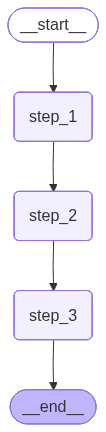

In [28]:
class State(TypedDict):
    input: str

def step_1(state: State) -> State:
    return state

def step_2(state: State) -> State:
    if len(state['input']) > 5:
        human_response = interrupt(
            f"Received input longer than 5 characters: {state['input']}"
        )

        return {"input": human_response}
    return state

def step_3(state: State) -> State:
    return state

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
# Encounters an error
initial_input = {"input": "hello world"}
thread = {"configurable": {"thread_id": "11"}}

for event in graph.stream(
    initial_input, thread, stream_mode="values"
):
    print(event)

{'input': 'hello world'}
{'input': 'hello world'}
{'input': 'hello world', '__interrupt__': (Interrupt(value='Received input longer than 5 characters: hello world', id='9ad2c91610f24576104fb759c10c3663'),)}


In [34]:
# To update state and resume
command = Command(resume="Hi!")
for event in graph.stream(
    command,
    thread,
    stream_mode="values"
):
    print(event)

{'input': 'Hi!'}


---

# Time Travel

Viewing, replaying and forking prior states.

- `get_state_history(<thread>)`: Returns the entire history of the graph invocation

## Replay

Replaying an already executed graph from an intermediate state

- `Graph.stream(None, {<checkpoint_id>, <thread_id>})`: Enables a __REPLAY__ of the graph i.e starting from the checkpoint_id, the graph results are shown in order with NO changes

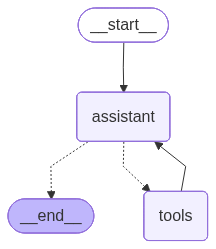

In [35]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY", "")
)
llm_with_tools = llm.bind_tools(tools)

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=InMemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "15"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

In [43]:
# Get all the replay states
all_states = [s for s in graph.get_state_history(thread)]
len(all_states)

20

In [44]:
# Get the replay state
to_replay = all_states[-2]
to_replay.config

{'configurable': {'thread_id': '15',
  'checkpoint_ns': '',
  'checkpoint_id': '1f158dab-12be-6e8b-8000-983f31152141'}}

In [45]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (eb0nm18tr)
 Call ID: eb0nm18tr
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================
Tool Calls:
  multiply (gsfx6v0e4)
 Call ID: gsfx6v0e4
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The function call was requested.


## Forking

When the state of the graph changes then the graph has to execute on the new information and NOT playback from the old one

In [46]:
to_fork = all_states[-2]
to_fork.values['messages']

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='bdcc7d09-966a-4761-8120-0049d18ed30c')]

In [47]:
to_fork.config

{'configurable': {'thread_id': '15',
  'checkpoint_ns': '',
  'checkpoint_id': '1f158dab-12be-6e8b-8000-983f31152141'}}

In [52]:
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(
        content="Multiple 5 and 8",
        id=to_fork.values['messages'][0].id
    )]}
)

In [54]:
fork_config

{'configurable': {'thread_id': '15',
  'checkpoint_ns': '',
  'checkpoint_id': '1f158dc2-4907-64fd-8001-dea6fd063db0'}}

In [ ]:
for event in graph.stream(None, fork_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

In [56]:
%load_ext watermark
%watermark

Last updated: 2026-05-26T16:28:08.734969+08:00

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.13.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 16
Architecture: 64bit

